### DIMENSIONALITY REDUCTION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

### Effect of outliers

In [2]:
data = load_breast_cancer()
Xdf=pd.DataFrame(data['data'],columns=data.feature_names)
ydf = pd.DataFrame({'target':data['target']})

/var/folders/81/kn1rwxy912vgf5sqnk7n_zd80000gn/T/ipykernel_67256/3281497892.py:2: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  Xdf.hist(ax=ax)


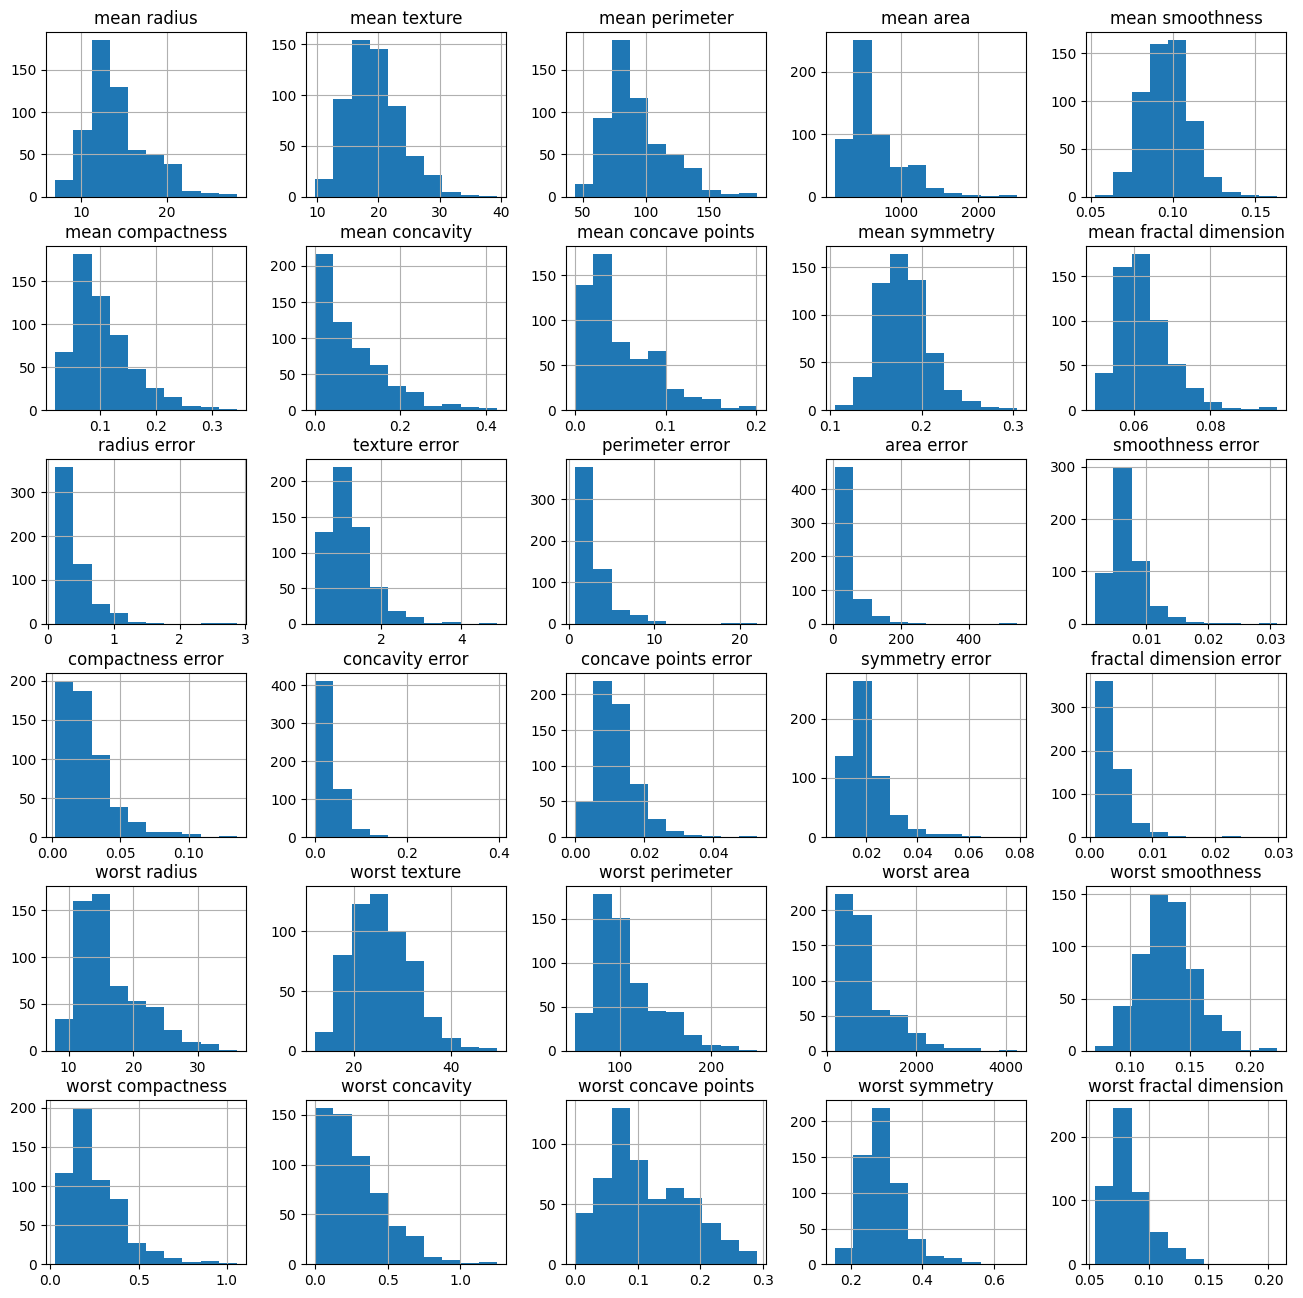

In [3]:
fix, ax = plt.subplots(figsize=(16,16))
Xdf.hist(ax=ax)
plt.show()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xdf.values)

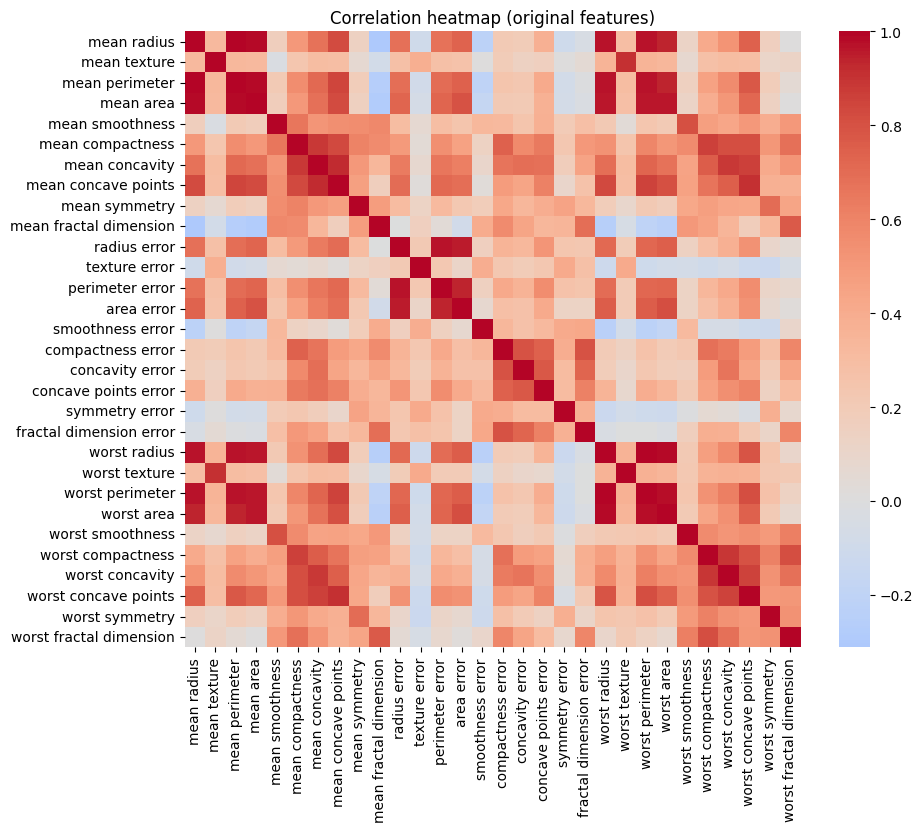

In [39]:
import seaborn as sns
# Correlation matrix
corr = Xdf.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap (original features)")
plt.show()

In [26]:
import numpy as np
from scipy.stats import pointbiserialr

feature_corrs = []

for j in range(X_scaled.shape[1]):
    r, _ = pointbiserialr(ydf.values.flatten(), X_scaled[:, j])
    feature_corrs.append(r)

feature_corrs = np.array(feature_corrs)

# Sort by absolute correlation
idx = np.argsort(np.abs(feature_corrs))[::-1]

print("Top correlated original features:")
for i in idx:
    print(f"Feature {i}: r = {feature_corrs[i]:.3f}")

Top correlated original features:
Feature 27: r = -0.794
Feature 22: r = -0.783
Feature 7: r = -0.777
Feature 20: r = -0.776
Feature 2: r = -0.743
Feature 23: r = -0.734
Feature 0: r = -0.730
Feature 3: r = -0.709
Feature 6: r = -0.696
Feature 26: r = -0.660
Feature 5: r = -0.597
Feature 25: r = -0.591
Feature 10: r = -0.567
Feature 12: r = -0.556
Feature 13: r = -0.548
Feature 21: r = -0.457
Feature 24: r = -0.421
Feature 28: r = -0.416
Feature 1: r = -0.415
Feature 17: r = -0.408
Feature 4: r = -0.359
Feature 8: r = -0.330
Feature 29: r = -0.324
Feature 15: r = -0.293
Feature 16: r = -0.254
Feature 19: r = -0.078
Feature 14: r = 0.067
Feature 9: r = 0.013
Feature 11: r = 0.008
Feature 18: r = 0.007


# PCA

Number of components for 90% explained variance: 7


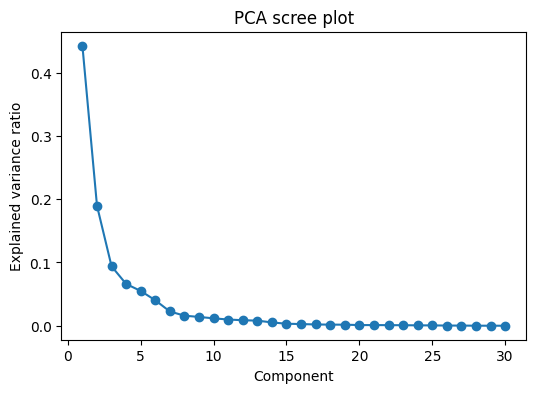

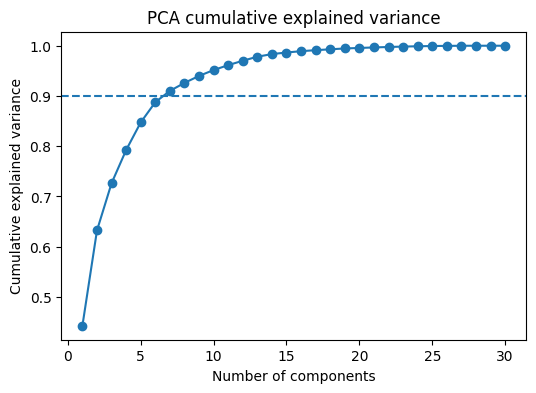

In [ ]:
from sklearn.decomposition import PCA

# Fit full PCA
pca_full = PCA()
pca_full.fit(X_scaled)


# Explained variance ratio
evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Smallest number of PCs explaining at least 90% variance
n_90 = np.argmax(cum_evr >= 0.90) + 1
print(f"Number of components for 90% explained variance: {n_90}")

# Scree plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(evr) + 1), evr, marker='o')
plt.xlabel("Component")
plt.ylabel("Explained variance ratio")
plt.title("PCA scree plot")
plt.show()

# Cumulative explained variance
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_evr) + 1), cum_evr, marker='o')
plt.axhline(0.90, linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.show()

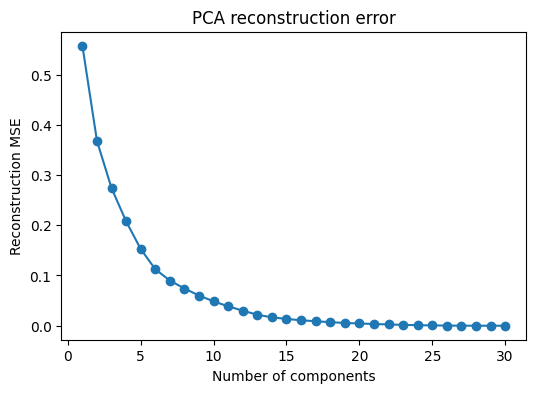

In [5]:
from sklearn.metrics import mean_squared_error

dims = range(1, X_scaled.shape[1] + 1)
recon_errors = []

for d in dims:
    pca = PCA(n_components=d)
    X_proj = pca.fit_transform(X_scaled)
    X_rec = pca.inverse_transform(X_proj)
    err = mean_squared_error(X_scaled, X_rec)
    recon_errors.append(err)

plt.figure(figsize=(6, 4))
plt.plot(dims, recon_errors, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Reconstruction MSE")
plt.title("PCA reconstruction error")
plt.show()

In [34]:
X_pca = pca_full.transform(X_scaled)
pc_corrs = []

for j in range(X_pca.shape[1]):
    r, _ = pointbiserialr(ydf.values.flatten(), X_pca[:, j])
    pc_corrs.append(r)

pc_corrs = np.array(pc_corrs)


print("Correlation of PCs with target:")
for i, r in enumerate(pc_corrs):
    print(f"PC{i+1}: r = {r:.3f}")



Correlation of PCs with target:
PC1: r = -0.785
PC2: r = 0.188
PC3: r = 0.165
PC4: r = -0.128
PC5: r = -0.099
PC6: r = 0.011
PC7: r = 0.078
PC8: r = -0.064
PC9: r = -0.000
PC10: r = 0.007
PC11: r = -0.015
PC12: r = -0.009
PC13: r = -0.098
PC14: r = 0.081
PC15: r = 0.106
PC16: r = 0.002
PC17: r = 0.038
PC18: r = 0.076
PC19: r = 0.057
PC20: r = 0.064
PC21: r = -0.044
PC22: r = -0.023
PC23: r = -0.021
PC24: r = -0.075
PC25: r = -0.009
PC26: r = -0.057
PC27: r = 0.030
PC28: r = 0.011
PC29: r = -0.046
PC30: r = 0.026


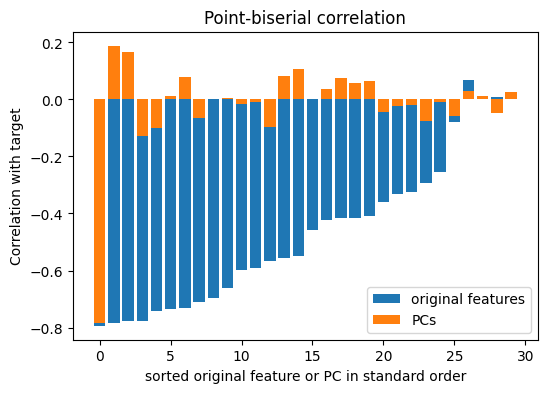

In [37]:
plt.figure(figsize=(6,4))
plt.bar(range(len(feature_corrs)), feature_corrs[idx], label='original features')
plt.bar(range(len(pc_corrs)), pc_corrs, label='PCs')
plt.title("Point-biserial correlation")
plt.xlabel("sorted original feature or PC in standard order")
plt.ylabel("Correlation with target")
plt.legend()
plt.show()

# Kernel PCA

Kernel PCA components for 90% kernel variance: 261


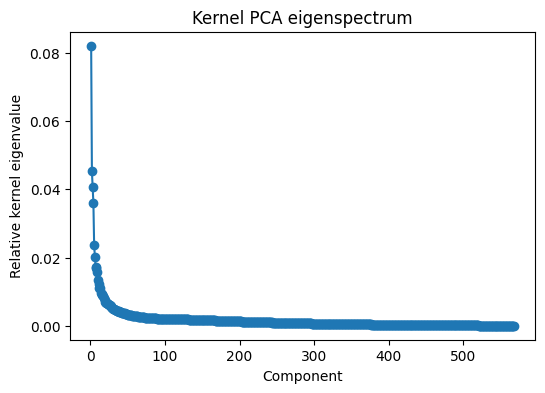

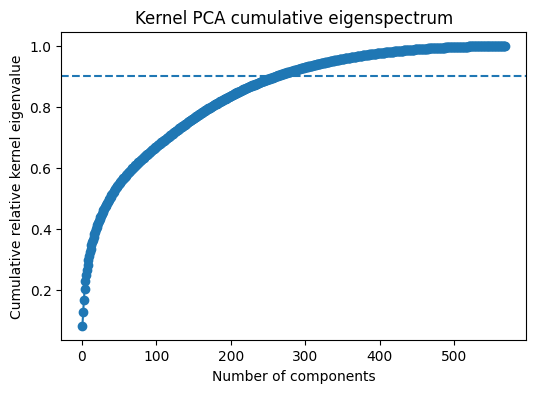

In [42]:
from sklearn.decomposition import KernelPCA

# RADIAL BASIS FUNCTION, I.E. RADIAL KERNEL
kpca_full_rbf = KernelPCA(
    n_components=None,
    kernel="rbf",
    gamma=0.1,
    fit_inverse_transform=False,
    eigen_solver="auto"
)

kpca_full_rbf.fit(X_scaled)

# Depending on sklearn version, this may be available as eigenvalues_ or lambdas_
eigvals = kpca_full_rbf.eigenvalues_

eigvals_ratio = eigvals / eigvals.sum()
cum_eigvals_ratio = np.cumsum(eigvals_ratio)

n_90_kpca = np.argmax(cum_eigvals_ratio >= 0.90) + 1
print(f"Kernel PCA components for 90% kernel variance: {n_90_kpca}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(eigvals_ratio) + 1), eigvals_ratio, marker='o')
plt.xlabel("Component")
plt.ylabel("Relative kernel eigenvalue")
plt.title("Kernel PCA eigenspectrum")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_eigvals_ratio) + 1), cum_eigvals_ratio, marker='o')
plt.axhline(0.90, linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative relative kernel eigenvalue")
plt.title("Kernel PCA cumulative eigenspectrum")
plt.show()

Kernel PCA components for 90% kernel eigenvalue mass: 19


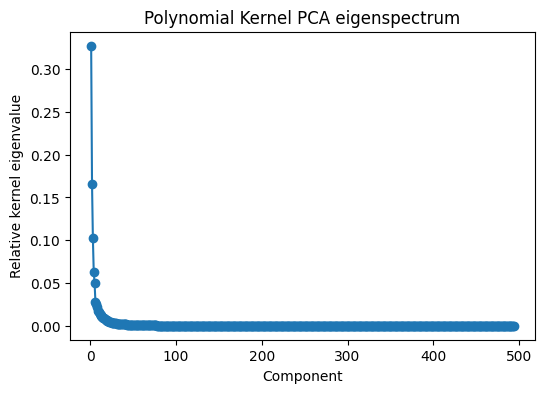

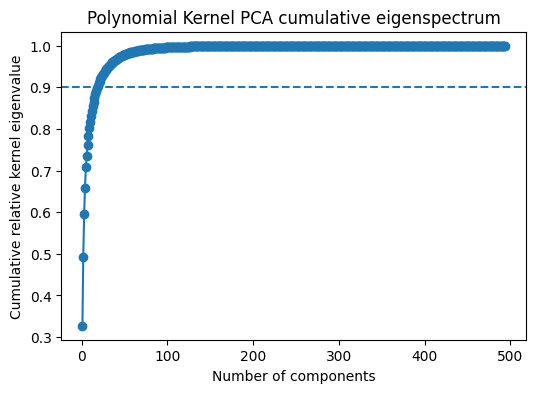

In [43]:
# POLYNOMIAL KERNEL

kpca_full_poly = KernelPCA(
    n_components=None,
    kernel="poly",
    degree=2,          # polynomial degree
    gamma=1.0,         # scaling of inner product
    coef0=1.0,         # adds lower-order terms
    fit_inverse_transform=False,
    eigen_solver="auto"
)

kpca_full_poly.fit(X_scaled)

# sklearn version compatibility
eigvals = getattr(kpca_full_poly, "eigenvalues_", None)
if eigvals is None:
    eigvals = kpca_full_poly.lambdas_

eigvals_ratio = eigvals / eigvals.sum()
cum_eigvals_ratio = np.cumsum(eigvals_ratio)

n_90_kpca = np.argmax(cum_eigvals_ratio >= 0.90) + 1
print(f"Kernel PCA components for 90% kernel eigenvalue mass: {n_90_kpca}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(eigvals_ratio) + 1), eigvals_ratio, marker='o')
plt.xlabel("Component")
plt.ylabel("Relative kernel eigenvalue")
plt.title("Polynomial Kernel PCA eigenspectrum")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_eigvals_ratio) + 1), cum_eigvals_ratio, marker='o')
plt.axhline(0.90, linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative relative kernel eigenvalue")
plt.title("Polynomial Kernel PCA cumulative eigenspectrum")
plt.show()

We compute the point-biserial correlation between the binary target and each kernel PCA coordinate as a descriptive measure of class alignment in the embedding. Since kernel PCA components are nonlinear features, these correlations are valid but less directly interpretable than in ordinary PCA.

Kernel PCA correlations (RBF): [0.6910782482583526, 0.169652377507997, -0.24180166933045966, 0.026966335739122244, -0.20682581960069218, -0.20922504471346937, 0.06058772100906797, 0.07043985490930688, 0.037925167960997624, 0.08830016404081724]


Kernel PCA correlations (poly): [-0.28818572366555545, -0.03314127854547069, 0.21114065433875573, 0.07737999566913446, 0.1862840370436945, -0.07207542280992413, 0.061038878778927275, -0.07090588919435727, 0.20328181820880967, 0.010741398676927309]


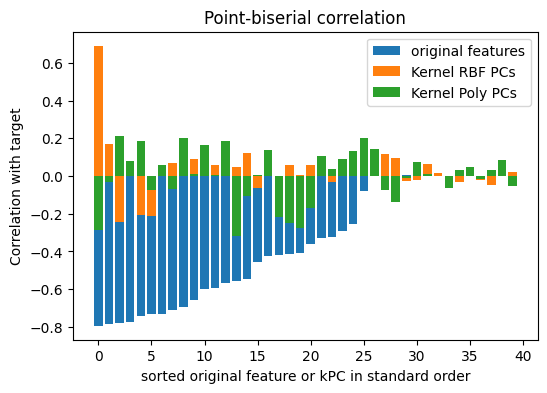

In [50]:
X_kpca_rbf = kpca_full_rbf.fit_transform(X_scaled)
X_kpca_poly = kpca_full_poly.fit_transform(X_scaled)

kpca_rbf_corrs = [
    pointbiserialr(ydf.values.flatten(), X_kpca_rbf[:, j])[0]
    for j in range(X_kpca_rbf.shape[1])
]
kpca_poly_corrs = [
    pointbiserialr(ydf.values.flatten(), X_kpca_poly[:, j])[0]
    for j in range(X_kpca_poly.shape[1])
]

print("Kernel PCA correlations (RBF):", kpca_rbf_corrs[:10])
print("\n\nKernel PCA correlations (poly):", kpca_poly_corrs[:10])

plt.figure(figsize=(6,4))
plt.bar(range(len(feature_corrs)), feature_corrs[idx], label='original features')
plt.bar(range(len(kpca_rbf_corrs))[:40], kpca_rbf_corrs[:40], label='Kernel RBF PCs')
plt.bar(range(len(kpca_poly_corrs))[:40], kpca_poly_corrs[:40], label='Kernel Poly PCs')
plt.title("Point-biserial correlation")
plt.xlabel("sorted original feature or kPC in standard order")
plt.ylabel("Correlation with target")
plt.legend()
plt.show()

# CHECK VISUALIZATION CAPABILITIES

In [51]:
pca_2d = PCA(
    n_components=2)

kpca_2d_poly = KernelPCA(
    n_components=2,
    kernel="poly",
    degree=2,
    gamma=1.0,
    coef0=1.0
)

kpca_2d_rbf = KernelPCA(
    n_components=2,
    kernel="rbf",
    gamma=0.1
)

X_pca_2d = pca_2d.fit_transform(X_scaled)
X_kpca_2d_poly = kpca_2d_poly.fit_transform(X_scaled)
X_kpca_2d_rbf = kpca_2d_rbf.fit_transform(X_scaled)

# MDS

In [52]:
from sklearn.manifold import MDS

mds = MDS(n_components=2, random_state=0)
X_mds = mds.fit_transform(X_scaled)

/Users/veronicaguidetti/miniforge3/envs/PACS/lib/python3.11/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


# ISOMAP

In [53]:
from sklearn.manifold import Isomap

iso = Isomap(n_components=2, n_neighbors=10)
X_iso = iso.fit_transform(X_scaled)

# UMAP

In [54]:
#! pip install umap-learn
import umap

umap_model = umap.UMAP(n_components=2)
X_umap = umap_model.fit_transform(X_scaled)

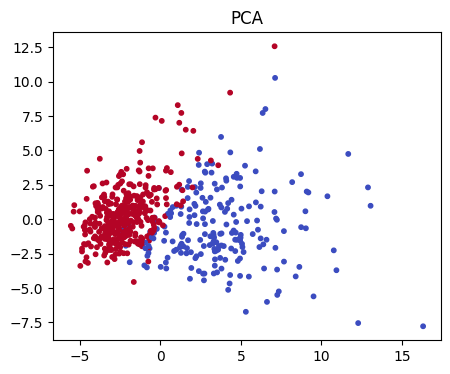

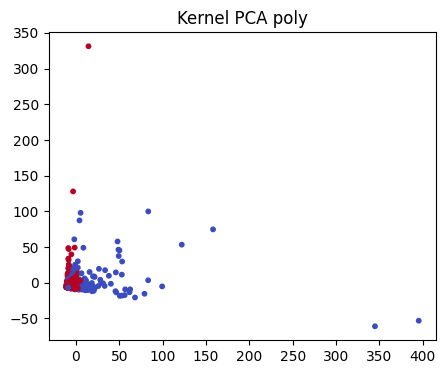

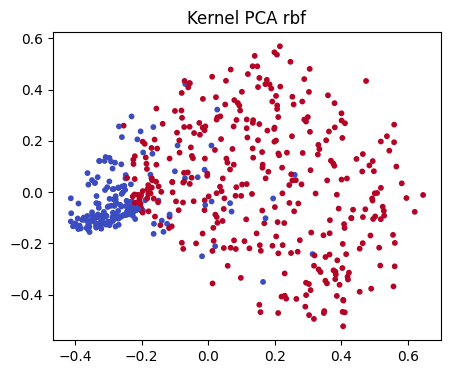

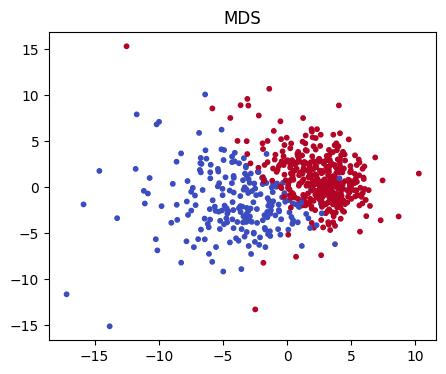

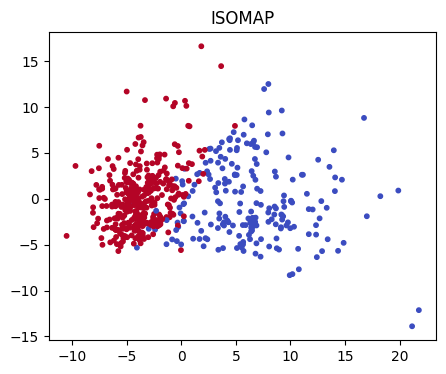

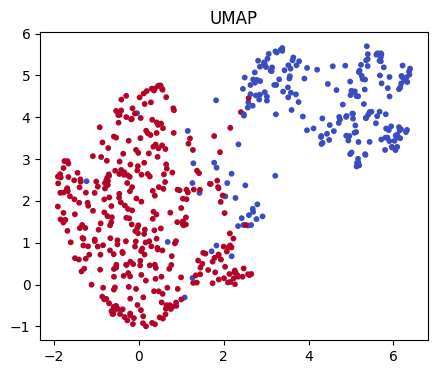

In [55]:
def plot_embedding(X_embedded, title, y):
    plt.figure(figsize=(5,4))
    plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y, cmap='coolwarm', s=10)
    plt.title(title)
    plt.show()


plot_embedding(X_pca_2d, "PCA", ydf.values)
plot_embedding(X_kpca_2d_poly, "Kernel PCA poly", ydf.values)
plot_embedding(X_kpca_2d_rbf, "Kernel PCA rbf", ydf.values)
plot_embedding(X_mds, "MDS", ydf.values)
plot_embedding(X_iso, "ISOMAP", ydf.values)
plot_embedding(X_umap, "UMAP", ydf.values)